# Beijing dataset

Load the Beijing PM dataset for the experiments in this notebook.

In [3]:
import pandas as pd
import bnlearn as bn
from tabulate import tabulate

beijing_df = pd.read_csv("BeijingPM20100101_20151231.csv")
beijing_df.head()
beijing_dfNoNA = beijing_df.dropna()
beijing_dfNoNAnumeric = beijing_dfNoNA.replace({"cbwd": {"cv": 0, "N": 1, "NE": 2, "E": 3, "SE": 4, "S": 5, "SW": 6, "W": 7, "NW": 8}})
beijing_dfNoNAnumeric.head()



c:\Users\olive\Documents\GitHub\DAI\.venv\Lib\site-packages\bnlearn\__init__.py:19: RuntimeWarning: [bnlearn] Using 'threading' backend instead of 'loky' because Windows + Python 3.14.2 causes joblib/loky crashes.
  warnings.warn(


,No,year,month,day,hour,season,PM_Dongsi,PM_Dongsihuan,PM_Nongzhanguan,PM_US Post,DEWP,HUMI,PRES,TEMP,cbwd,Iws,precipitation,Iprec
27824,27825,2013,3,5,8,1,117.0,166.0,140.0,150.0,-6.0,59.0,1019.0,1.0,0,0.89,0.0,0.0
27825,27826,2013,3,5,9,1,131.0,165.0,152.0,163.0,-8.0,38.0,1019.0,5.0,0,1.78,0.0,0.0
27826,27827,2013,3,5,10,1,141.0,173.0,128.0,172.0,-8.0,31.0,1018.0,8.0,0,2.67,0.0,0.0
27828,27829,2013,3,5,12,1,169.0,182.0,3.0,181.0,-9.0,23.0,1017.0,11.0,0,4.45,0.0,0.0
27829,27830,2013,3,5,13,1,169.0,169.0,3.0,187.0,-9.0,22.0,1015.0,12.0,0,5.34,0.0,0.0


[bnlearn] >Computing best DAG using [direct-lingam]
[bnlearn] >Compute edge strength with direct-lingam
[bnlearn] >250 edges are removed with P-value > 0.05 based on direct-lingam
[bnlearn] >Converting source-target into adjacency matrix..
[bnlearn] >Making the matrix symmetric..
[bnlearn] >Set node properties.
[bnlearn]> Set edge weights based on the [dof] test statistic.
[bnlearn] >Converting source-target into adjacency matrix..
[bnlearn] >Making the matrix symmetric..
[bnlearn] >Set edge properties.
[bnlearn] >Plot based on Bayesian model


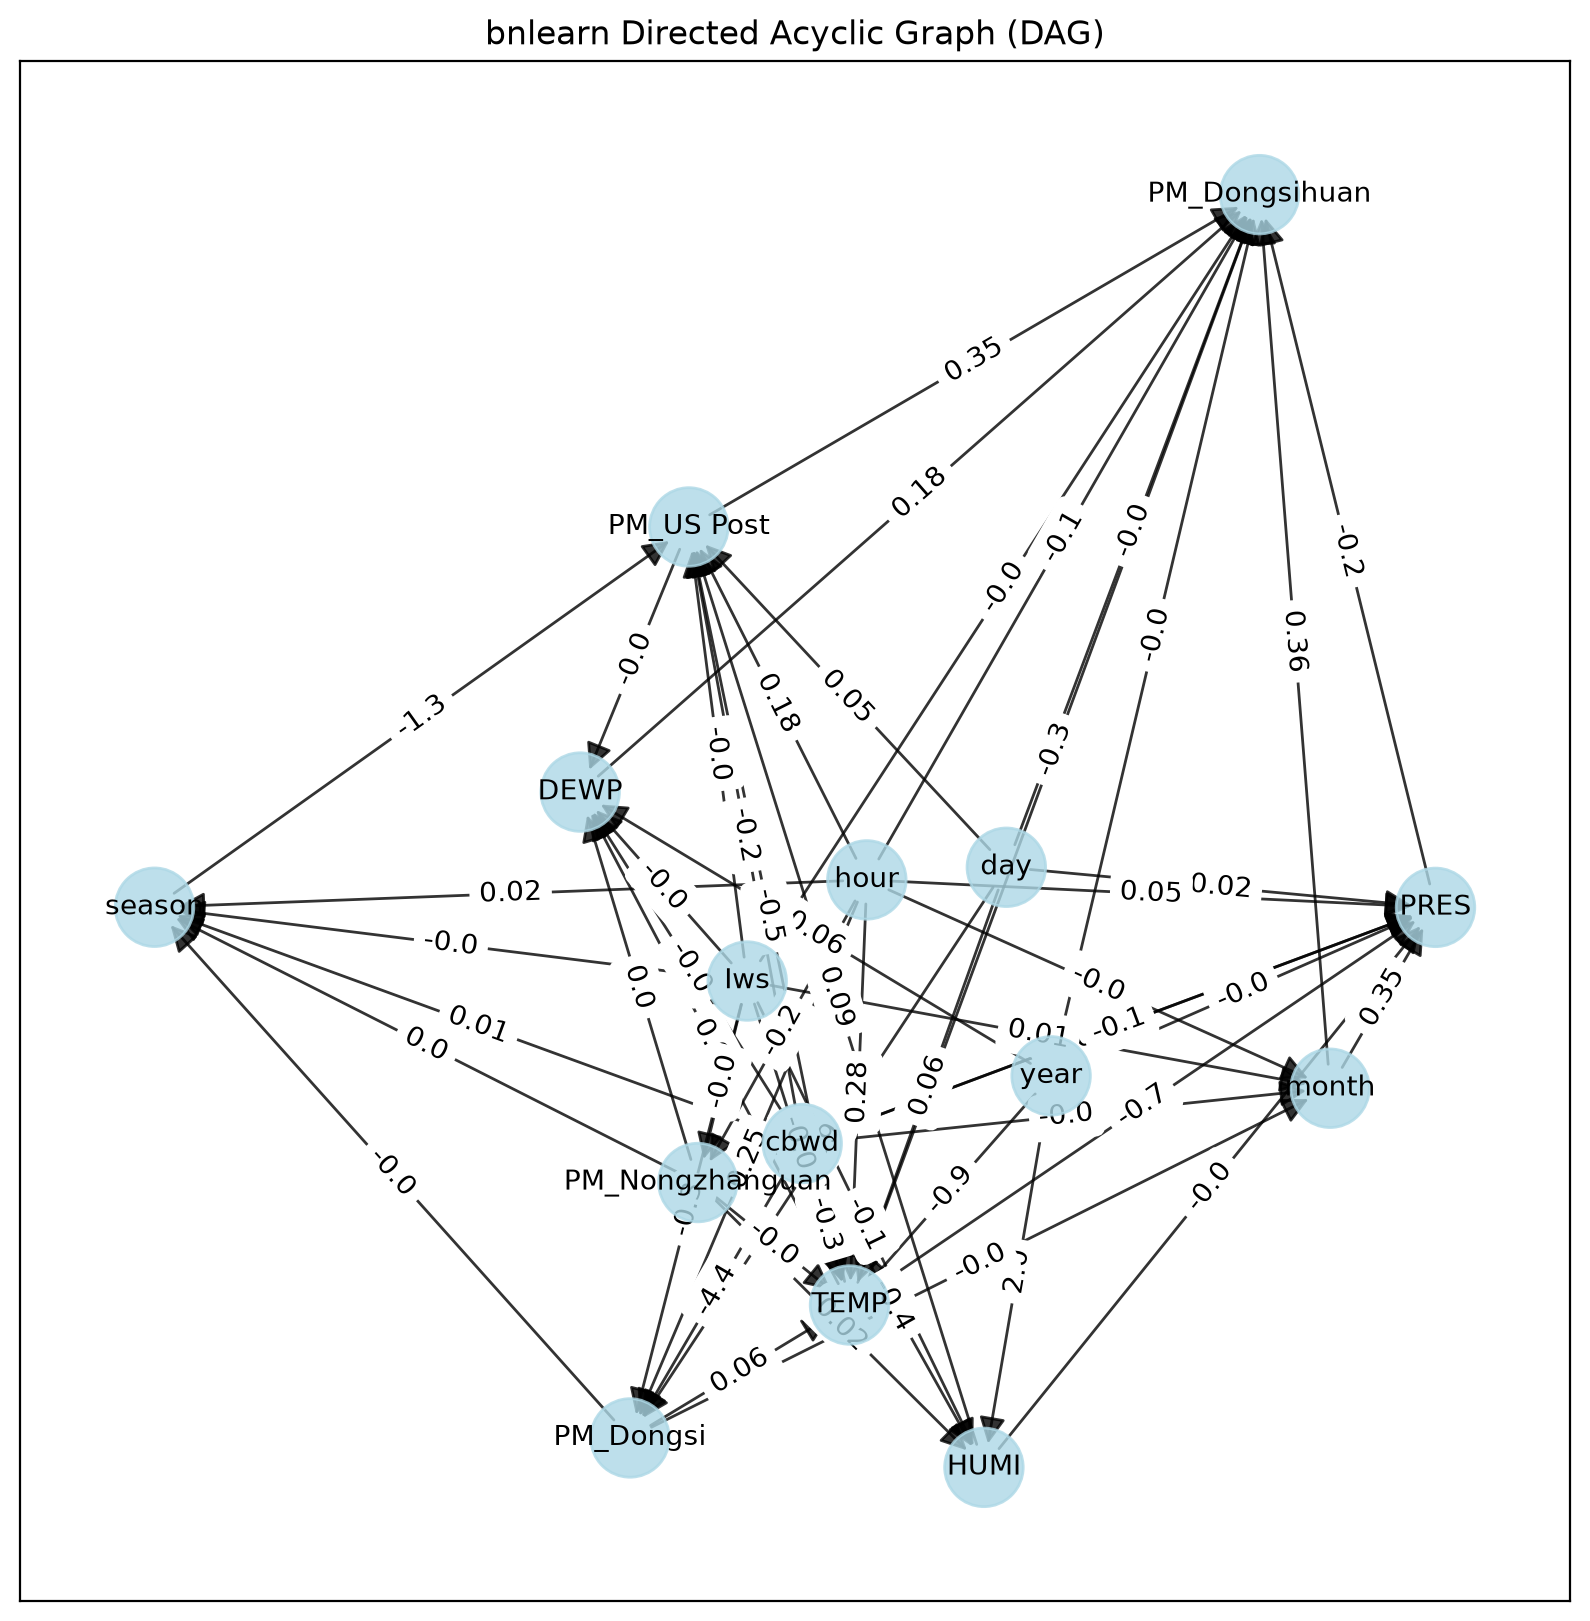

[14-06-2026 14:41:16] [setgraphviz.setgraphviz] [INFO] System found: windows
[14-06-2026 14:41:16] [setgraphviz.setgraphviz] [INFO] System found: windows
[14-06-2026 14:41:16] [setgraphviz.setgraphviz] [INFO] Create graphviz directory: C:\Users\olive\AppData\Local\Temp\GRAPHVIZ
[14-06-2026 14:41:16] [setgraphviz.setgraphviz] [INFO] Create graphviz directory: C:\Users\olive\AppData\Local\Temp\GRAPHVIZ
[14-06-2026 14:41:16] [setgraphviz.setgraphviz] [INFO] Downloading graphviz..
[14-06-2026 14:41:16] [setgraphviz.setgraphviz] [INFO] Downloading graphviz..
[14-06-2026 14:41:23] [setgraphviz.setgraphviz] [INFO] Extracting graphviz files.
[14-06-2026 14:41:23] [setgraphviz.setgraphviz] [INFO] Extracting graphviz files.
[14-06-2026 14:41:24] [setgraphviz.setgraphviz] [INFO] Set Graphviz path in environment.
[14-06-2026 14:41:24] [setgraphviz.setgraphviz] [INFO] Set Graphviz path in environment.


'dotgraph_auto_mpg_lingam_direct.pdf'

In [4]:
# Perform structure learning
model = bn.structure_learning.fit(beijing_dfNoNAnumeric,
                                methodtype='direct-lingam',
                                params_lingam={'random_state': 2})

# Compute edge strength
model = bn.independence_test(model, beijing_dfNoNAnumeric, prune=True)

# Create visualizations
bn.plot(model)
dotgraph = bn.plot_graphviz(model)
dotgraph
dotgraph.view(filename=r'dotgraph_auto_mpg_lingam_direct')